In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from io import StringIO
%matplotlib inline

Pressure ratio per material:
  Al2024: PR = 1.945
  Al6061: PR = 1.945
  Cu: PR = 1.364
  SS304: PR = 1.001
  Ti64: PR = 1.144
Pi range: 4.129746492288426 ~ 92738.301443481


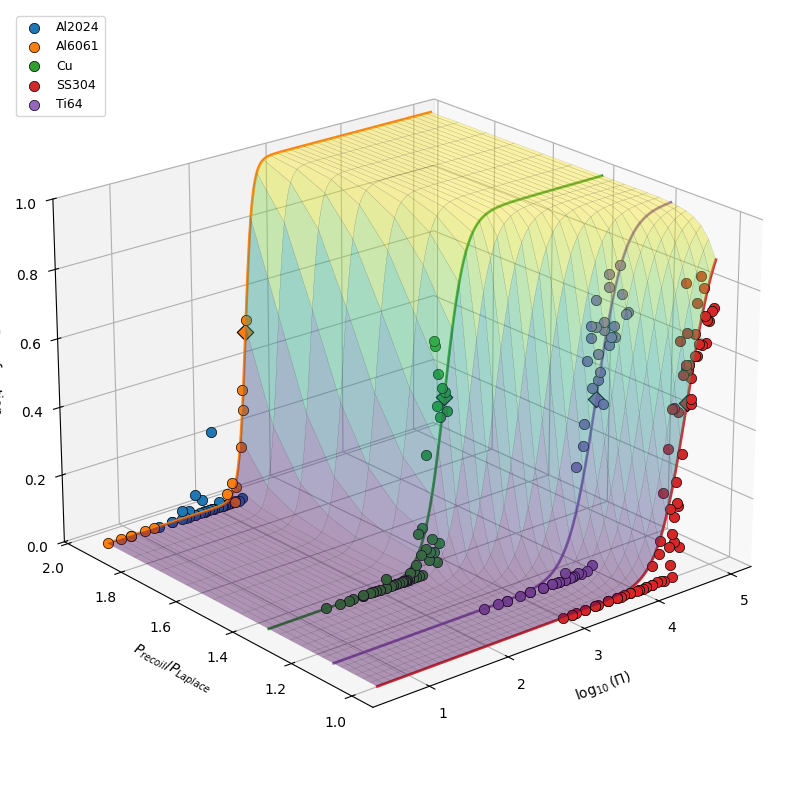

saved


In [3]:

# ============================================================
# 材料热物性
# ============================================================
materials = {
    "Al2024": dict(k=85.5,  rho=2500.0, cp=1140.0, Tm=905.0,  Tb=2792.0, Lv=1.22e7, A=0.04),
    "Al6061": dict(k=90.0,  rho=2415.0, cp=1170.0, Tm=915.0,  Tb=2792.0, Lv=1.22e7, A=0.04),
    "Cu":     dict(k=146.0, rho=7960.0, cp=495.0,  Tm=1358.0, Tb=2835.0, Lv=5.31e6, A=0.12),
    "SS304":  dict(k=28.0,  rho=6900.0, cp=800.0,  Tm=1727.0, Tb=3134.0, Lv=7.45e6, A=0.40),
    "Ti64":   dict(k=33.4,  rho=3920.0, cp=831.0,  Tm=1923.0, Tb=3560.0, Lv=9.88e6, A=0.27),
}
for p in materials.values():
    p["alpha"] = p["k"] / (p["rho"] * p["cp"])

d_char = 70e-6
oh_props = {
    "SS304":  dict(eta=6.0e-3, rho_l=7900.0, gamma=1.80),
    "Ti64":   dict(eta=4.5e-3, rho_l=4430.0, gamma=1.65),
    "Cu":     dict(eta=4.0e-3, rho_l=8060.0, gamma=1.30),
    "Al2024": dict(eta=1.3e-3, rho_l=2700.0, gamma=0.87),
    "Al6061": dict(eta=1.3e-3, rho_l=2700.0, gamma=0.87),
}
def Oh(mat):
    p = oh_props[mat]
    return p["eta"] / np.sqrt(p["rho_l"] * p["gamma"] * d_char)

def Pi(P, V_mms, mat):
    p = materials[mat]
    V = V_mms * 1e-3
    return (p["Lv"] * p["rho"] * p["A"] * P * V)/ (p["k"]**2 * (p["Tb"] - p["Tm"])**2)

# ============================================================
# Pressure ratio
# ============================================================
p_atm   = 101325.0
R_gas   = 8.314
theta   = 0.0
r_keyhole_default = d_char / 2

pressure_props = {
    "Ti64":   dict(dHv=422000, T_boil=3560, gamma=1.65),
    "SS304":  dict(dHv=341000, T_boil=3090, gamma=1.80),
    "Al2024": dict(dHv=294000, T_boil=2792, gamma=0.90),
    "Al6061": dict(dHv=294000, T_boil=2792, gamma=0.90),
    "Cu":     dict(dHv=305000, T_boil=2835, gamma=1.30),
}

def pressure_ratio(mat, T_surface=None, r_keyhole=r_keyhole_default):
    p = pressure_props[mat]
    if T_surface is None:
        T_surface = p["T_boil"]*1.05
    P_recoil  = 0.54 * p_atm * np.exp(
        (p["dHv"] / R_gas) * (1/p["T_boil"] - 1/T_surface)
    )
    P_laplace = 2 * p["gamma"] * np.cos(theta) / r_keyhole
    return P_recoil / P_laplace

# ============================================================
# 数据
# ============================================================
raw = """material,P,V,Mode,Pore
Al2024,400,1000,Keyhole,0
Al2024,400,1500,VD,0
Al2024,400,2000,Conduction,0
Al2024,400,2500,Conduction,0
Al2024,400,3000,Conduction,0
Al2024,400,3500,Conduction,0
Al2024,400,4000,Conduction,0
Al2024,400,4500,None,
Al2024,400,5000,Conduction,0
Al2024,600,1000,Keyhole,0.0017
Al2024,600,1500,VD,0
Al2024,600,2000,VD,0
Al2024,600,2500,VD,0
Al2024,600,3000,VD,0
Al2024,600,3500,VD,0
Al2024,600,4000,VD,0
Al2024,600,4500,VD,0
Al2024,600,5000,VD,0
Al2024,800,1000,Keyhole,0.0253
Al2024,800,1500,VD,0.059
Al2024,800,2000,VD,0.00107
Al2024,800,2500,VD,0
Al2024,800,3000,VD,0
Al2024,800,3500,VD,0
Al2024,800,4000,VD,0
Al2024,800,4500,VD,0
Al2024,800,5000,VD,0
Al2024,1000,1000,Keyhole,0.0186
Al2024,1000,1500,VD,0.0377
Al2024,1000,2000,VD,0.236
Al2024,1000,2500,VD,0.0138
Al2024,1000,3000,VD,0
Al2024,1000,3500,VD,0
Al2024,1000,4000,VD,0.00293
Al2024,1000,4500,VD,0
Al2024,1000,5000,VD,0.00491
Al6061,100,1000,Conduction,0
Al6061,200,1000,Conduction,0
Al6061,100,1500,Conduction,0
Al6061,200,1500,Conduction,0
Al6061,100,2000,Conduction,0
Al6061,200,2000,Conduction,0
Al6061,1000,6000,VD,0.33
Al6061,800,6000,VD,0.044
Al6061,600,6000,VD,0.0305
Al6061,1000,7000,VD,0.536
Al6061,800,7000,VD,0.1605
Al6061,600,7000,VD,0.059
Al6061,800,7500,VD,0.27
Al6061,600,7500,Conduction,0
Cu,400,1000,conduction,0
Cu,400,1500,conduction,0
Cu,400,2000,conduction,0
Cu,400,2500,conduction,0
Cu,400,3000,conduction,0
Cu,400,3500,conduction,0
Cu,400,4000,conduction,0
Cu,400,4500,None,
Cu,400,5000,conduction,0
Cu,600,1000,VD,0
Cu,600,1500,VD,0
Cu,600,2000,VD,0.024
Cu,600,2500,VD,0
Cu,600,3000,VD,0
Cu,600,3500,conduction,0
Cu,600,4000,conduction,0
Cu,600,4500,conduction,0
Cu,600,5000,conduction,0
Cu,800,1000,VD,0.000591
Cu,800,1500,VD,0.000183
Cu,800,2000,VD,0
Cu,800,2500,VD,0
Cu,800,3000,VD,0.00322
Cu,800,3500,VD,0.0213
Cu,800,4000,VD,0.126
Cu,800,4500,VD,0.14
Cu,800,5000,VD,0.0724
Cu,1000,1000,VD,0.000652
Cu,1000,1500,VD,0.000119
Cu,1000,2000,VD,0.00212
Cu,1000,2500,VD,0.0184
Cu,1000,3000,VD,0.0348
Cu,1000,3500,VD,0.0603
Cu,1000,4000,VD,0.35
Cu,1000,4500,VD,0.0606
Cu,1000,5000,VD,0.671
Cu,400,500,keyhole,0.0009
Cu,400,750,conduction,0
Cu,600,750,Keyhole,0
Cu,800,750,keyhole,0.0008
Cu,1000,750,keyhole,0
Cu,600,3250,VD,0
Cu,600,3750,conduction,0
Cu,800,5500,VD,0.0364
Cu,1000,5500,VD,0.4818
Cu,1000,5250,VD,0.6554
Cu,1000,5750,VD,0.5703
Cu,800,6000,VD,0.0956
Cu,1000,6000,VD,0.4459
Cu,600,5500,conduction,0
Cu,1000,6500,VD,0.5262
Cu,800,6500,VD,0.0565
Cu,1000,7000,VD,0.5148
Cu,800,7000,VD,0.0235
Cu,1000,7500,VD,0.4583
Cu,800,7500,VD,0.07617
Cu,600,6000,conduction,0
Cu,400,5500,conduction,0
SS304,400,1000,none,0
SS304,400,1500,none,0
SS304,400,2000,none,0
SS304,400,2500,none,0
SS304,400,3000,none,0
SS304,400,3500,none,0.00295
SS304,400,4000,none,0.00292
SS304,400,4500,none,
SS304,400,5000,none,0.0942
SS304,600,1000,none,0
SS304,600,1500,none,0
SS304,600,2000,none,0.0555
SS304,600,2500,none,0.0847
SS304,600,3000,none,0.384
SS304,600,3500,none,0.498
SS304,600,4000,none,0.685
SS304,600,4500,none,0.585
SS304,600,5000,none,0.703
SS304,800,1000,none,0
SS304,800,1500,none,0
SS304,800,2000,none,0.26
SS304,800,2500,none,0.496
SS304,800,3000,none,0.483
SS304,800,3500,none,0.845
SS304,800,4000,none,0.595
SS304,800,4500,none,0.492
SS304,800,5000,none,0.629
SS304,1000,1000,none,0
SS304,1000,1500,none,0.123
SS304,1000,2000,none,0.208
SS304,1000,2500,none,0.218
SS304,1000,3000,none,0.6
SS304,1000,3500,none,0.57
SS304,1000,4000,none,0.777
SS304,1000,4500,none,0.85
SS304,1000,5000,none,0.814
SS304,800,500,keyhole,0
SS304,1000,500,keyhole,0
SS304,100,750,VD,0
SS304,150,750,VD,0
SS304,200,750,VD,0
SS304,400,750,Keyhole,0
SS304,600,750,Keyhole,0
SS304,800,750,Keyhole,0
SS304,1000,750,Keyhole,0
SS304,100,1000,VD,0
SS304,200,1000,VD,0
SS304,100,1500,conduction,0
SS304,150,1500,conduction,0
SS304,200,1500,VD,0
SS304,200,2000,VD,0
SS304,400,5250,VD,0.04155
SS304,400,5500,VD,0.1318
SS304,400,5750,VD,0.1797
SS304,400,6000,VD,0.1055
SS304,400,7000,VD,0.3551
SS304,400,7500,VD,0.61
SS304,300,7500,VD,0.002515
SS304,300,6000,VD,0
SS304,200,500,keyhole,0
SS304,400,500,keyhole,0
SS304,600,500,keyhole,0
SS304,600,5500,VD,0.6063
SS304,800,5500,VD,0.6587
SS304,1000,5500,VD,0.6563
SS304,400,6000,VD,0.2795
SS304,600,6000,VD,0.5089
SS304,800,6000,VD,0.6539
SS304,1000,6000,VD,0.71622
SS304,400,6500,VD,0.2079
SS304,600,6500,VD,0.6923
SS304,800,6500,VD,0.7328
SS304,1000,6500,VD,0.7427
SS304,1000,7000,VD,0.747
SS304,800,7000,VD,0.7197
SS304,600,7000,VD,0.6273
SS304,400,7000,VD,0.083
Ti64,400,1000,none,0
Ti64,400,1500,none,0
Ti64,400,2000,none,0
Ti64,400,2500,none,0
Ti64,400,3000,none,0
Ti64,400,3500,none,0
Ti64,400,4000,none,0
Ti64,400,4500,none,
Ti64,400,5000,none,0
Ti64,600,1000,none,0
Ti64,600,1500,none,0
Ti64,600,2000,none,0.0206
Ti64,600,2500,none,0
Ti64,600,3000,none,0.00651
Ti64,600,3500,none,0.618
Ti64,600,4000,none,0.679
Ti64,600,4500,none,0.785
Ti64,600,5000,none,0.629
Ti64,800,1000,none,0
Ti64,800,1500,none,0
Ti64,800,2000,none,0.321
Ti64,800,2500,none,0.438
Ti64,800,3000,none,0.715
Ti64,800,3500,none,0.707
Ti64,800,4000,none,0.574
Ti64,800,4500,none,0.69
Ti64,800,5000,none,0.809
Ti64,1000,1000,none,0
Ti64,1000,1500,none,0
Ti64,1000,2000,none,0.375
Ti64,1000,2500,none,0.537
Ti64,1000,3000,none,0.552
Ti64,1000,3500,none,0.715
Ti64,1000,4000,none,0.846
Ti64,1000,4500,none,0.665
Ti64,1000,5000,none,0.66
Ti64,100,1000,conduction,0
Ti64,200,1000,keyhole,0
Ti64,100,1500,conduction,0
Ti64,200,1500,VD,0
Ti64,100,2000,VD,0
Ti64,200,2000,VD,0
Ti64,1000,6000,VD,0.7775
Ti64,800,6000,VD,0.6926
Ti64,600,6000,VD,0.4798
Ti64,400,6000,VD,0.002847
Ti64,1000,7000,VD,0.718
Ti64,800,7000,VD,0.8613
Ti64,600,7000,VD,0.6425
Ti64,400,7000,VD,0.01549
Ti64,1000,7500,VD,0.722
"""
df = pd.read_csv(StringIO(raw))
df["Pore"] = pd.to_numeric(df["Pore"], errors="coerce")
df = df.dropna(subset=["Pore"]).copy()
df["Pi"] = df.apply(lambda r: Pi(r["P"], r["V"], r["material"]), axis=1)
df["Oh"] = df["material"].map(Oh)
df["PR"] = df["material"].map(pressure_ratio)

print("Pressure ratio per material:")
for m in materials:
    print(f"  {m}: PR = {pressure_ratio(m):.3f}")
print("Pi range:", df["Pi"].min(), "~", df["Pi"].max())

# ============================================================
# 改进的半透明拟合曲面 (带折痕)
#   - 每个材料 fit logistic(log10 Pi) -> (L, k, x0)
#   - PR 方向用 *线性* 插值 (C0): 在每个 PR 行有可见折痕, 显示拐点
#   - 加密 logPi 网格让 S 形拐点更清晰; PR 方向只在材料间细分,
#     这样每条 fit 曲线本身就是一条网格线, 折痕一目了然
# ============================================================
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

def _logistic(x, k, x0):
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))

# 排除 Al2024 (蓝色) 不参与 fit; 散点仍会画出来
mats_all = ["Al6061", "Cu", "SS304", "Ti64"]
fits_local = {}
for m in mats_all:
    sub = df[df["material"] == m].sort_values("Pi")
    x = np.log10(sub["Pi"].values)
    y = sub["Pore"].values
    if len(x) < 4:
        continue
    x0_init = x[np.argmin(np.abs(y - 0.5))]
    try:
        popt, _ = curve_fit(_logistic, x, y,
                            p0=[4.0, x0_init],
                            bounds=([0.1, x.min()-2],
                                    [50.0, x.max()+5]),
                            maxfev=10000)
        fits_local[m] = popt
    except Exception as e:
        print(f"{m} fit failed: {e}")

# 收集 (PR, L, k, x0), 同 PR 取均值
PR_arr = np.array([pressure_ratio(m) for m in fits_local])
k_arr  = np.array([fits_local[m][0]  for m in fits_local])
x0_arr = np.array([fits_local[m][1]  for m in fits_local])
uniq_PR, inv = np.unique(PR_arr, return_inverse=True)
k_u  = np.array([k_arr[inv == i].mean()  for i in range(len(uniq_PR))])
x0_u = np.array([x0_arr[inv == i].mean() for i in range(len(uniq_PR))])

# *** 线性插值 -> 在每个材料 PR 处保留折痕 ***
fk  = interp1d(uniq_PR, k_u,  kind="linear", fill_value="extrapolate")
fx0 = interp1d(uniq_PR, x0_u, kind="linear", fill_value="extrapolate")

# 网格
logPi_grid = np.linspace(np.log10(df["Pi"].min()),
                         np.log10(df["Pi"].max()), 200)
n_between  = 6
PR_pieces  = [np.linspace(uniq_PR[i], uniq_PR[i+1], n_between+1)
              for i in range(len(uniq_PR)-1)]
PR_grid    = np.unique(np.concatenate(PR_pieces))

LP, PR_g   = np.meshgrid(logPi_grid, PR_grid)
Z = 1.0 / (1.0 + np.exp(-fk(PR_g) * (LP - fx0(PR_g))))
Z = np.clip(Z, 0, 1)

# ============================================================
# 3D scatter + 半透明拟合曲面
# ============================================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(LP, PR_g, Z,
                cmap="viridis", alpha=0.40,
                linewidth=0.15, edgecolor=(0.2, 0.2, 0.2, 0.25),
                antialiased=True,
                rstride=1, cstride=4, shade=True)

colors = {"Al2024":"tab:blue","Al6061":"tab:orange","Cu":"tab:green",
          "SS304":"tab:red","Ti64":"tab:purple"}
for m, popt in fits_local.items():
    pr = pressure_ratio(m)
    xs = logPi_grid
    ys = _logistic(xs, *popt)
    ax.plot(xs, np.full_like(xs, pr), ys,
            color=colors[m], lw=2.0, alpha=0.95, zorder=4)
    k, x0 = popt
    ax.scatter([x0], [pr], [0.5],
               color=colors[m], marker="D", s=70,
               edgecolor="k", linewidth=0.8, zorder=6)

for mat, sub in df.groupby("material"):
    ax.scatter(np.log10(sub["Pi"]), sub["PR"], sub["Pore"],
               c=colors[mat], label=mat, s=55,
               edgecolor="k", linewidth=0.5, depthshade=False, zorder=5)

ax.set_xlabel(r"$\log_{10}(\Pi)$", labelpad=8)
ax.set_ylabel(r"$P_{recoil}/P_{Laplace}$", labelpad=8)
ax.set_zlabel("Pore fraction", labelpad=6)
ax.set_zlim(0, 1)
ax.legend(loc="upper left", fontsize=9)
ax.view_init(elev=22, azim=-130)
plt.tight_layout()
plt.show()
print("saved")
